In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\asus\OneDrive\Documents\Ecommerce-Sales-Analytics\Data\Cleaned\ecommerce_sales_final.csv"
)

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [4]:
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,...,Month,Month Name,Quarter,Year Month,Age Group,Delivered Flag,Returned Flag,In Transit Flag,Revenue,Order Value Segment
0,CUST0268,Male,North,49.0,Monitor,Electronics,300.0,5,1500,13.31,...,12,December,Q4,2023-12,46-55,0,1,0,1500,High
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,...,4,April,Q2,2023-04,18-25,0,0,1,200,Low
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,...,8,August,Q3,2023-08,46-55,0,1,0,300,Low
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,...,1,January,Q1,2023-01,18-25,1,0,0,500,Low
4,CUST0173,Female,South,49.0,Laptop,Electronics,1500.0,3,4500,5.40,...,1,January,Q1,2023-01,46-55,1,0,0,4500,Very High


In [5]:
df.shape

(1000, 25)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\asus\OneDrive\Documents\Ecommerce-Sales-Analytics\Data\Cleaned\ecommerce_sales_final.csv"
)

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [4]:
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,...,Month,Month Name,Quarter,Year Month,Age Group,Delivered Flag,Returned Flag,In Transit Flag,Revenue,Order Value Segment
0,CUST0268,Male,North,49.0,Monitor,Electronics,300.0,5,1500,13.31,...,12,December,Q4,2023-12,46-55,0,1,0,1500,High
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,...,4,April,Q2,2023-04,18-25,0,0,1,200,Low
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,...,8,August,Q3,2023-08,46-55,0,1,0,300,Low
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,...,1,January,Q1,2023-01,18-25,1,0,0,500,Low
4,CUST0173,Female,South,49.0,Laptop,Electronics,1500.0,3,4500,5.40,...,1,January,Q1,2023-01,46-55,1,0,0,4500,Very High


In [5]:
df.shape

(1000, 25)

In [6]:
df.columns

Index(['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category',
       'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee',
       'Shipping Status', 'Order Date', 'Difference', 'Price Check', 'Year',
       'Month', 'Month Name', 'Quarter', 'Year Month', 'Age Group',
       'Delivered Flag', 'Returned Flag', 'In Transit Flag', 'Revenue',
       'Order Value Segment'],
      dtype='str')

In [7]:
total_revenue = df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1346600


In [8]:
total_orders = len(df)

print("Total Orders:", total_orders)

Total Orders: 1000


In [9]:
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 3008


In [10]:
unique_customers = df["Customer ID"].nunique()

print("Unique Customers:", unique_customers)

Unique Customers: 292


In [11]:
average_order_value = (
    total_revenue / total_orders
)

print("Average Order Value:", average_order_value)

Average Order Value: 1346.6


In [12]:
print("===== E-COMMERCE BUSINESS KPIs =====")
print("Total Revenue       :", total_revenue)
print("Total Orders        :", total_orders)
print("Total Quantity      :", total_quantity)
print("Unique Customers    :", unique_customers)
print("Average Order Value :", round(average_order_value, 2))

===== E-COMMERCE BUSINESS KPIs =====
Total Revenue       : 1346600
Total Orders        : 1000
Total Quantity      : 3008
Unique Customers    : 292
Average Order Value : 1346.6


In [13]:
product_revenue = (
    df.groupby("Product Name")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product Name
Laptop        696000
Smartphone    353600
Monitor       150900
Smartwatch     74200
Headphones     37000
Keyboard       22900
Mouse          12000
Name: Revenue, dtype: int64

In [14]:
top_5_products = product_revenue.head(5)

top_5_products

Product Name
Laptop        696000
Smartphone    353600
Monitor       150900
Smartwatch     74200
Headphones     37000
Name: Revenue, dtype: int64

In [15]:
product_quantity = (
    df.groupby("Product Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity

Product Name
Monitor       503
Laptop        464
Keyboard      458
Smartphone    442
Mouse         400
Smartwatch    371
Headphones    370
Name: Quantity, dtype: int64

In [16]:
product_orders = (
    df.groupby("Product Name")
    .size()
    .sort_values(ascending=False)
)

product_orders.head(5)

Product Name
Monitor       181
Laptop        154
Keyboard      145
Smartphone    142
Mouse         136
dtype: int64

In [17]:
product_summary = (
    df.groupby("Product Name")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Product Name", "count"),
        Average_Price=("Unit Price", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

product_summary

,Revenue,Quantity,Orders,Average_Price
Product Name,,,,
Laptop,696000,464,154,1541.806769
Smartphone,353600,442,142,818.135894
Monitor,150900,503,181,308.892600
Smartwatch,74200,371,122,200.000000
Headphones,37000,370,120,101.788401
Keyboard,22900,458,145,50.740028
Mouse,12000,400,136,30.946800


In [18]:
product_summary.head(10)

,Revenue,Quantity,Orders,Average_Price
Product Name,,,,
Laptop,696000,464,154,1541.806769
Smartphone,353600,442,142,818.135894
Monitor,150900,503,181,308.892600
Smartwatch,74200,371,122,200.000000
Headphones,37000,370,120,101.788401
Keyboard,22900,458,145,50.740028
Mouse,12000,400,136,30.946800


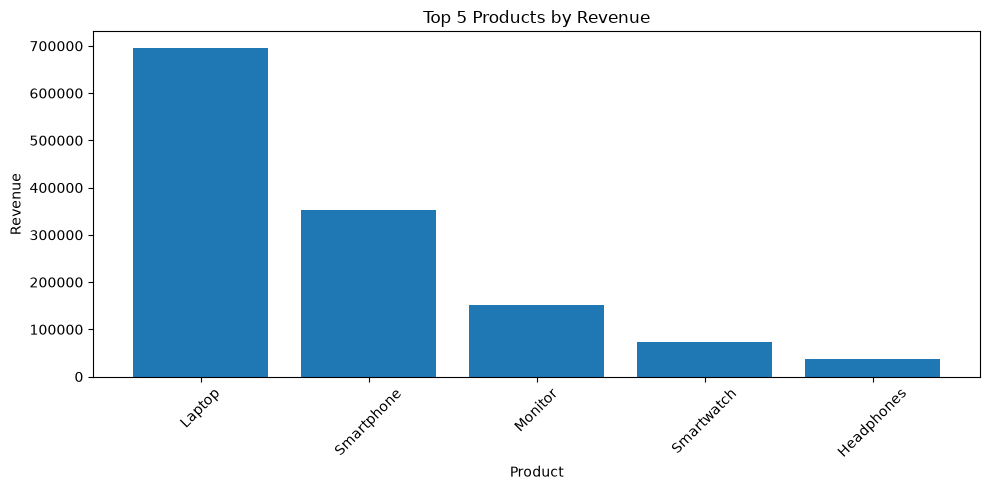

In [19]:
top_products = product_summary.head(5)

plt.figure(figsize=(10, 5))

plt.bar(
    top_products.index,
    top_products["Revenue"]
)

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [20]:
category_revenue = (
    df.groupby("Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Revenue, dtype: int64

In [21]:
category_quantity = (
    df.groupby("Category")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

category_quantity

Category
Electronics    1409
Accessories    1228
Wearables       371
Name: Quantity, dtype: int64

In [22]:
category_orders = (
    df.groupby("Category")
    .size()
    .sort_values(ascending=False)
)

category_orders

Category
Electronics    477
Accessories    401
Wearables      122
dtype: int64

In [23]:
category_summary = (
    df.groupby("Category")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity=("Quantity", "sum"),
        Orders=("Category", "count"),
        Average_Order_Value=("Revenue", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

category_summary

,Revenue,Quantity,Orders,Average_Order_Value
Category,,,,
Electronics,1200500,1409,477,2516.771488
Wearables,74200,371,122,608.196721
Accessories,71900,1228,401,179.301746


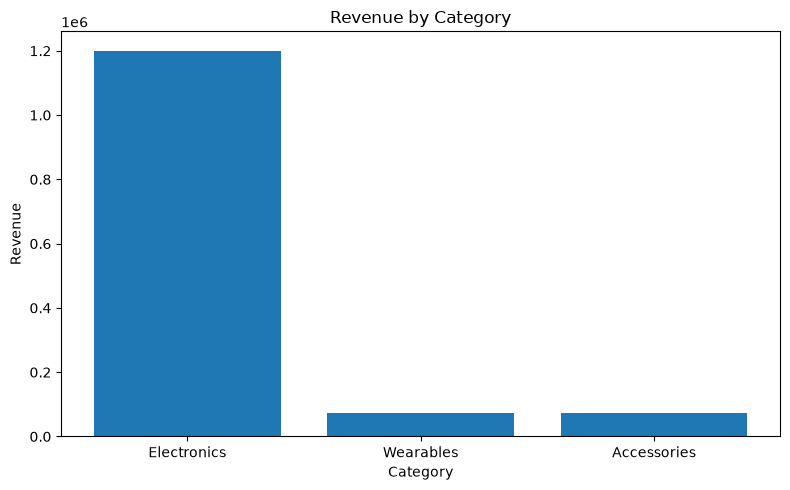

In [24]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_summary.index,
    category_summary["Revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [25]:
category_summary["Revenue %"] = (
    category_summary["Revenue"]
    / category_summary["Revenue"].sum()
    * 100
)

category_summary

,Revenue,Quantity,Orders,Average_Order_Value,Revenue %
Category,,,,,
Electronics,1200500,1409,477,2516.771488,89.150453
Wearables,74200,371,122,608.196721,5.510174
Accessories,71900,1228,401,179.301746,5.339373


In [26]:
region_revenue = (
    df.groupby("Region")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

Region
East       329950
North      324990
West       323390
South      301040
Unknown     67230
Name: Revenue, dtype: int64

In [27]:
region_orders = (
    df.groupby("Region")
    .size()
    .sort_values(ascending=False)
)

region_orders

Region
West       246
South      244
East       231
North      229
Unknown     50
dtype: int64

In [28]:
region_quantity = (
    df.groupby("Region")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

region_quantity

Region
West       733
South      726
East       715
North      702
Unknown    132
Name: Quantity, dtype: int64

In [29]:
region_summary = (
    df.groupby("Region")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Region", "count"),
        Quantity=("Quantity", "sum"),
        Average_Order_Value=("Revenue", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

region_summary

,Revenue,Orders,Quantity,Average_Order_Value
Region,,,,
East,329950,231,715,1428.354978
North,324990,229,702,1419.170306
West,323390,246,733,1314.593496
South,301040,244,726,1233.770492
Unknown,67230,50,132,1344.600000


In [30]:
region_summary["Revenue %"] = (
    region_summary["Revenue"]
    / region_summary["Revenue"].sum()
    * 100
)

region_summary

,Revenue,Orders,Quantity,Average_Order_Value,Revenue %
Region,,,,,
East,329950,231,715,1428.354978,24.502451
North,324990,229,702,1419.170306,24.134116
West,323390,246,733,1314.593496,24.015298
South,301040,244,726,1233.770492,22.355562
Unknown,67230,50,132,1344.600000,4.992574


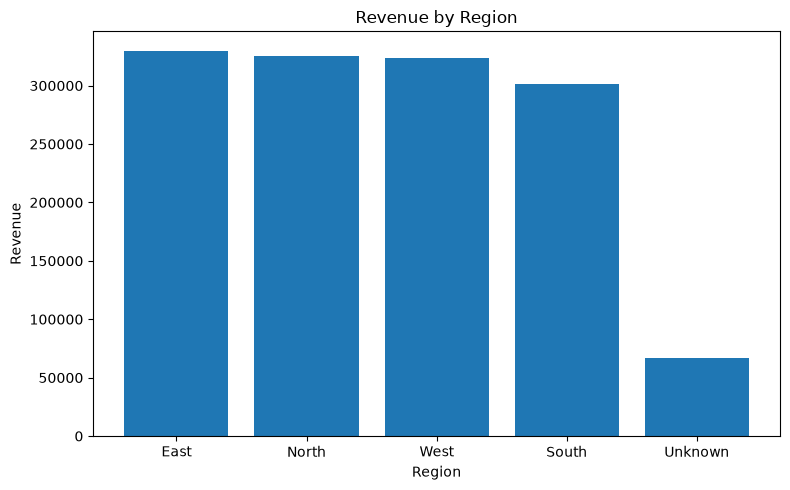

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_summary.index,
    region_summary["Revenue"]
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

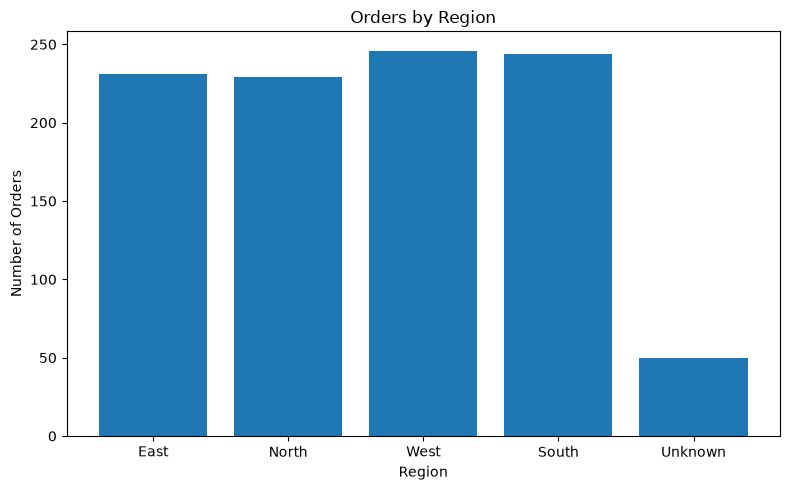

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    region_summary.index,
    region_summary["Orders"]
)

plt.title("Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [33]:
monthly_revenue = (
    df.groupby("Year Month")["Revenue"]
    .sum()
)

monthly_revenue

Year Month
2023-01    141360
2023-02     78910
2023-03     67660
2023-04     87840
2023-05    120080
2023-06    129450
2023-07    103160
2023-08    108050
2023-09    119490
2023-10    118240
2023-11    147150
2023-12    113830
2024-01     11380
Name: Revenue, dtype: int64

In [34]:
monthly_revenue = monthly_revenue.sort_index()

monthly_revenue

Year Month
2023-01    141360
2023-02     78910
2023-03     67660
2023-04     87840
2023-05    120080
2023-06    129450
2023-07    103160
2023-08    108050
2023-09    119490
2023-10    118240
2023-11    147150
2023-12    113830
2024-01     11380
Name: Revenue, dtype: int64

In [35]:
highest_revenue_month = monthly_revenue.idxmax()
highest_revenue_value = monthly_revenue.max()

print("Highest Revenue Month:", highest_revenue_month)
print("Revenue:", highest_revenue_value)

Highest Revenue Month: 2023-11
Revenue: 147150


In [36]:
lowest_revenue_month = monthly_revenue.idxmin()
lowest_revenue_value = monthly_revenue.min()

print("Lowest Revenue Month:", lowest_revenue_month)
print("Revenue:", lowest_revenue_value)

Lowest Revenue Month: 2024-01
Revenue: 11380


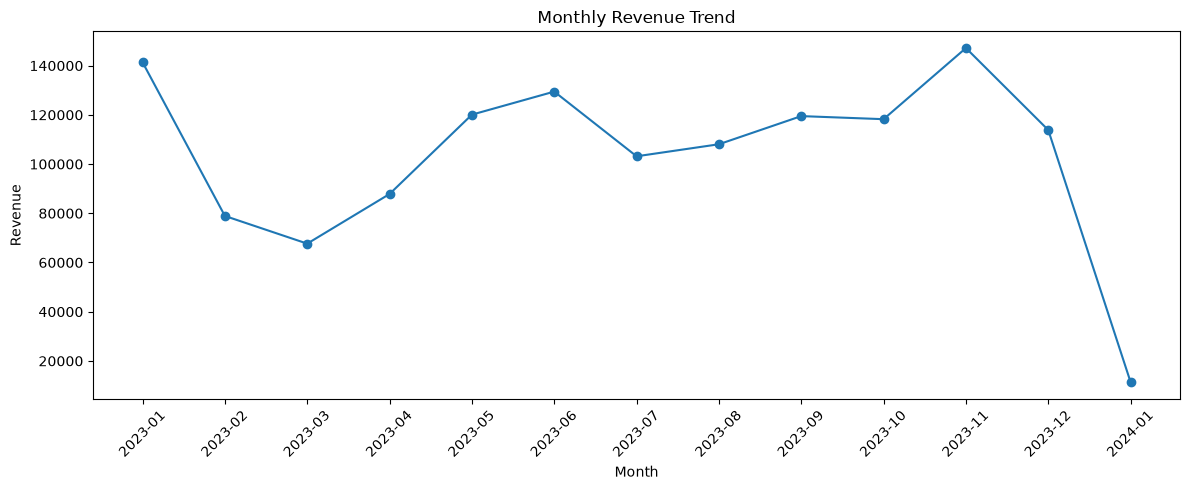

In [37]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
monthly_orders = (
    df.groupby("Year Month")
    .size()
    .sort_index()
)

monthly_orders

Year Month
2023-01    94
2023-02    74
2023-03    67
2023-04    66
2023-05    86
2023-06    90
2023-07    79
2023-08    84
2023-09    81
2023-10    91
2023-11    88
2023-12    80
2024-01    20
dtype: int64

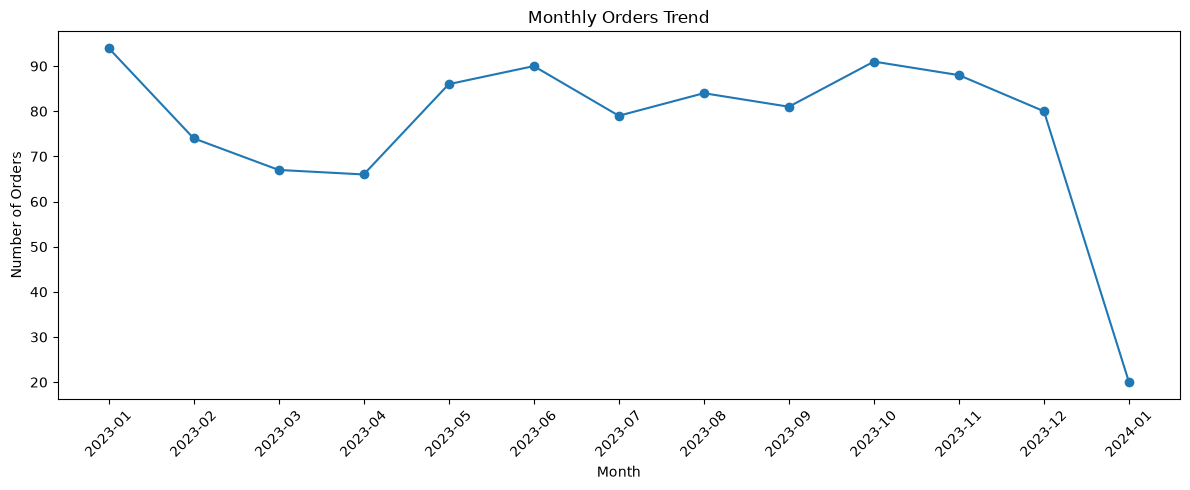

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders.index,
    monthly_orders.values,
    marker="o"
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [40]:
monthly_summary = (
    df.groupby("Year Month")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Customer ID", "count"),
        Quantity=("Quantity", "sum")
    )
    .sort_index()
)

monthly_summary

,Revenue,Orders,Quantity
Year Month,,,
2023-01,141360,94,298
2023-02,78910,74,201
2023-03,67660,67,210
2023-04,87840,66,189
2023-05,120080,86,267
2023-06,129450,90,274
2023-07,103160,79,226
2023-08,108050,84,239
2023-09,119490,81,240


In [41]:
monthly_summary["Average Order Value"] = (
    monthly_summary["Revenue"]
    / monthly_summary["Orders"]
)

monthly_summary

,Revenue,Orders,Quantity,Average Order Value
Year Month,,,,
2023-01,141360,94,298,1503.829787
2023-02,78910,74,201,1066.351351
2023-03,67660,67,210,1009.850746
2023-04,87840,66,189,1330.909091
2023-05,120080,86,267,1396.279070
2023-06,129450,90,274,1438.333333
2023-07,103160,79,226,1305.822785
2023-08,108050,84,239,1286.309524
2023-09,119490,81,240,1475.185185


In [42]:
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue

Customer ID
CUST0204    29100
CUST0095    22440
CUST0131    21180
CUST0139    18350
CUST0281    17850
            ...  
CUST0217       90
CUST0005       60
CUST0194       60
CUST0254       60
CUST0257       60
Name: Revenue, Length: 292, dtype: int64

In [43]:
top_10_customers = customer_revenue.head(10)

top_10_customers

Customer ID
CUST0204    29100
CUST0095    22440
CUST0131    21180
CUST0139    18350
CUST0281    17850
CUST0144    17320
CUST0200    16700
CUST0197    16150
CUST0064    14600
CUST0293    14200
Name: Revenue, dtype: int64

In [44]:
customer_orders = (
    df.groupby("Customer ID")
    .size()
    .sort_values(ascending=False)
)

customer_orders.head(10)

Customer ID
CUST0204    9
CUST0044    9
CUST0052    9
CUST0095    9
CUST0201    8
CUST0281    8
CUST0131    8
CUST0299    7
CUST0064    7
CUST0028    7
dtype: int64

In [45]:
customer_quantity = (
    df.groupby("Customer ID")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

customer_quantity.head(10)

Customer ID
CUST0095    34
CUST0204    33
CUST0052    29
CUST0299    26
CUST0028    25
CUST0281    25
CUST0044    24
CUST0131    24
CUST0144    22
CUST0174    22
Name: Quantity, dtype: int64

In [46]:
customer_summary = (
    df.groupby("Customer ID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Customer ID", "count"),
        Quantity=("Quantity", "sum"),
        Average_Order_Value=("Revenue", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

customer_summary.head(10)

,Revenue,Orders,Quantity,Average_Order_Value
Customer ID,,,,
CUST0204,29100,9,33,3233.333333
CUST0095,22440,9,34,2493.333333
CUST0131,21180,8,24,2647.500000
CUST0139,18350,7,22,2621.428571
CUST0281,17850,8,25,2231.250000
CUST0144,17320,5,22,3464.000000
CUST0200,16700,4,13,4175.000000
CUST0197,16150,5,18,3230.000000
CUST0064,14600,7,17,2085.714286


In [47]:
customer_summary["Revenue %"] = (
    customer_summary["Revenue"]
    / customer_summary["Revenue"].sum()
    * 100
)

customer_summary.head(10)

,Revenue,Orders,Quantity,Average_Order_Value,Revenue %
Customer ID,,,,,
CUST0204,29100,9,33,3233.333333,2.160998
CUST0095,22440,9,34,2493.333333,1.666419
CUST0131,21180,8,24,2647.500000,1.572850
CUST0139,18350,7,22,2621.428571,1.362691
CUST0281,17850,8,25,2231.250000,1.325561
CUST0144,17320,5,22,3464.000000,1.286202
CUST0200,16700,4,13,4175.000000,1.240160
CUST0197,16150,5,18,3230.000000,1.199317
CUST0064,14600,7,17,2085.714286,1.084212


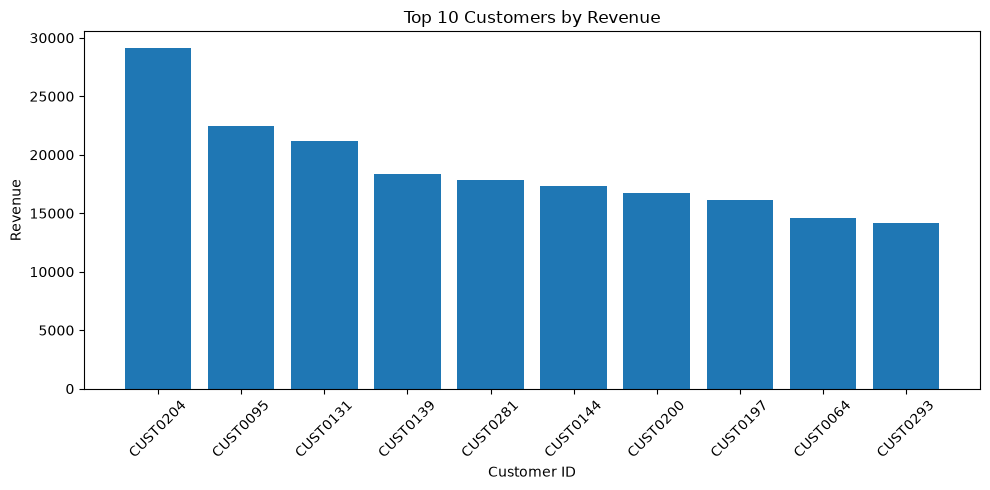

In [48]:
top_customers = customer_summary.head(10)

plt.figure(figsize=(10, 5))

plt.bar(
    top_customers.index.astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [49]:
customer_summary["Customer Segment"] = pd.cut(
    customer_summary["Revenue"],
    bins=[0, 2000, 5000, 10000, float("inf")],
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

In [50]:
customer_summary["Customer Segment"].value_counts()

Customer Segment
Low Value       106
High Value       93
Medium Value     67
VIP              26
Name: count, dtype: int64

In [52]:
shipping_status_count = (
    df["Shipping Status"]
    .value_counts()
)

shipping_status_count

Shipping Status
In Transit    329
Delivered     313
Returned      308
Unknown        50
Name: count, dtype: int64

In [53]:
shipping_status_percentage = (
    df["Shipping Status"]
    .value_counts(normalize=True)
    * 100
)

shipping_status_percentage

Shipping Status
In Transit    32.9
Delivered     31.3
Returned      30.8
Unknown        5.0
Name: proportion, dtype: float64

In [54]:
shipping_summary = pd.DataFrame({
    "Orders": shipping_status_count,
    "Percentage": shipping_status_percentage
})

shipping_summary

,Orders,Percentage
Shipping Status,,
In Transit,329,32.9
Delivered,313,31.3
Returned,308,30.8
Unknown,50,5.0


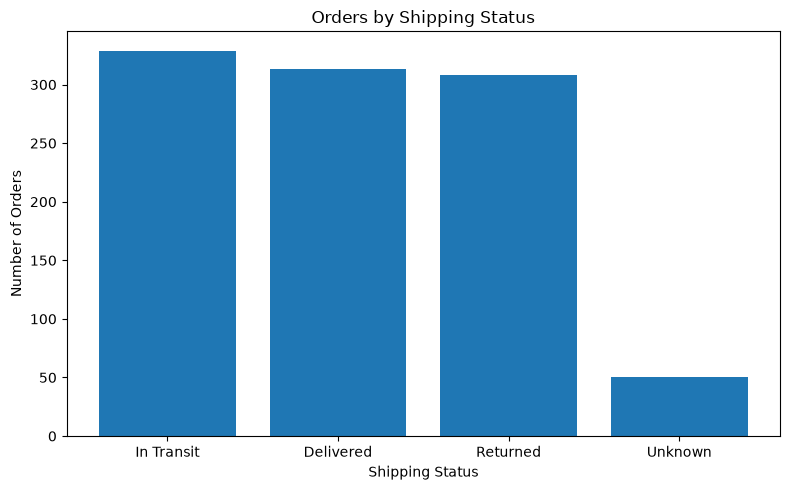

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    shipping_summary.index,
    shipping_summary["Orders"]
)

plt.title("Orders by Shipping Status")
plt.xlabel("Shipping Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [56]:
total_returns = (
    df["Returned Flag"].sum()
)

print("Total Returns:", total_returns)

Total Returns: 308


In [57]:
return_rate = (
    total_returns / total_orders
) * 100

print("Return Rate:", round(return_rate, 2), "%")

Return Rate: 30.8 %


In [58]:
returned_revenue = df.loc[
    df["Shipping Status"] == "Returned",
    "Revenue"
].sum()

print("Revenue from Returned Orders:", returned_revenue)

Revenue from Returned Orders: 415640


In [59]:
returns_by_product = (
    df[df["Shipping Status"] == "Returned"]
    .groupby("Product Name")
    .size()
    .sort_values(ascending=False)
)

returns_by_product

Product Name
Monitor       52
Laptop        49
Mouse         44
Keyboard      43
Smartphone    42
Headphones    40
Smartwatch    38
dtype: int64

In [60]:
returns_by_product.head(5)

Product Name
Monitor       52
Laptop        49
Mouse         44
Keyboard      43
Smartphone    42
dtype: int64

In [61]:
returns_by_category = (
    df[df["Shipping Status"] == "Returned"]
    .groupby("Category")
    .size()
    .sort_values(ascending=False)
)

returns_by_category

Category
Electronics    143
Accessories    127
Wearables       38
dtype: int64

In [62]:
returns_by_region = (
    df[df["Shipping Status"] == "Returned"]
    .groupby("Region")
    .size()
    .sort_values(ascending=False)
)

returns_by_region

Region
West       95
North      65
South      64
East       62
Unknown    22
dtype: int64

In [63]:
category_return_rate = (
    df.groupby("Category")["Returned Flag"]
    .mean()
    * 100
)

category_return_rate.sort_values(ascending=False)

Category
Accessories    31.670823
Wearables      31.147541
Electronics    29.979036
Name: Returned Flag, dtype: float64

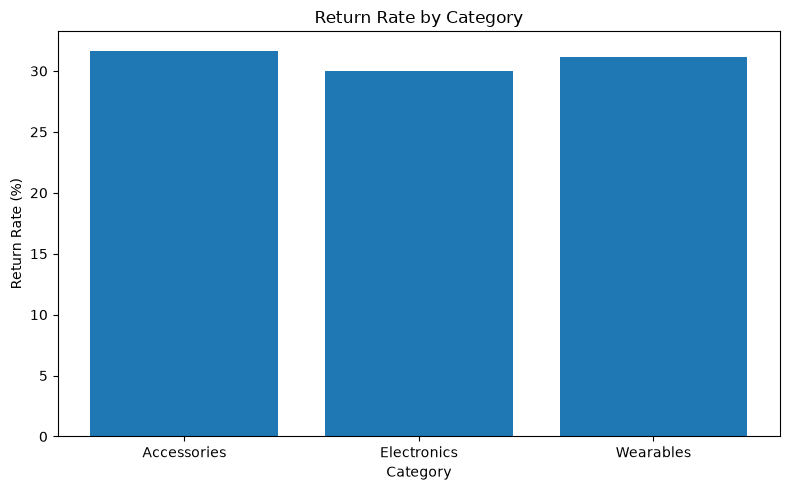

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_return_rate.index,
    category_return_rate.values
)

plt.title("Return Rate by Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")

plt.tight_layout()
plt.show()

In [65]:
numeric_columns = [
    "Age",
    "Unit Price",
    "Quantity",
    "Total Price",
    "Shipping Fee",
    "Revenue"
]

correlation = df[numeric_columns].corr()

correlation

,Age,Unit Price,Quantity,Total Price,Shipping Fee,Revenue
Age,1.000000,0.054737,0.016479,0.038586,0.024008,0.038586
Unit Price,0.054737,1.000000,0.002678,0.824360,0.016851,0.824360
Quantity,0.016479,0.002678,1.000000,0.360877,0.045812,0.360877
Total Price,0.038586,0.824360,0.360877,1.000000,0.003249,1.000000
Shipping Fee,0.024008,0.016851,0.045812,0.003249,1.000000,0.003249
Revenue,0.038586,0.824360,0.360877,1.000000,0.003249,1.000000


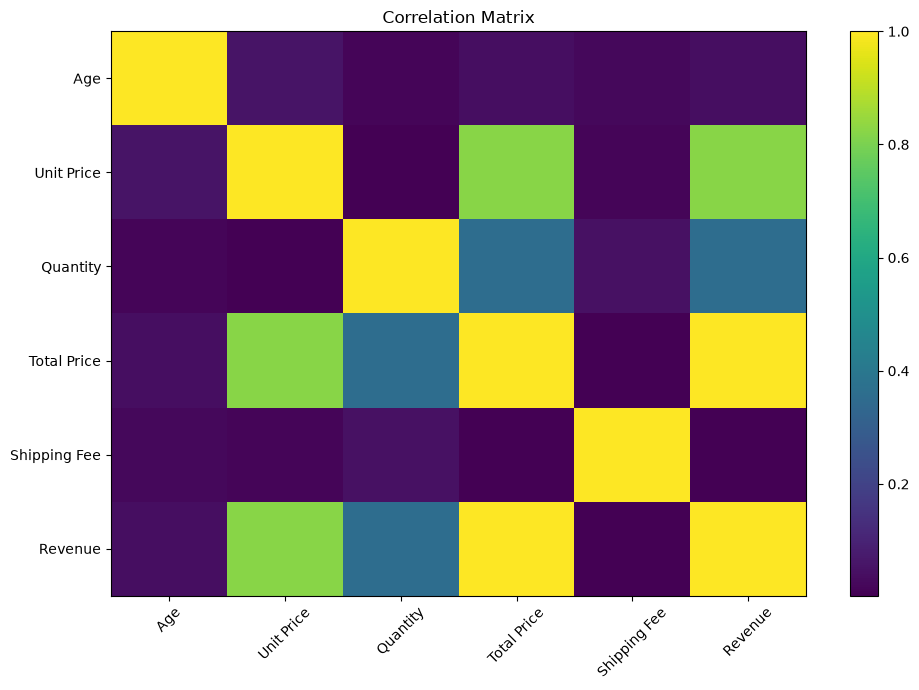

In [67]:
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [68]:
df["Revenue"].describe()

count    1000.000000
mean     1346.600000
std      1834.037877
min        30.000000
25%       200.000000
50%       600.000000
75%      1500.000000
max      7500.000000
Name: Revenue, dtype: float64

In [69]:
print("Mean Revenue:", df["Revenue"].mean())
print("Median Revenue:", df["Revenue"].median())

Mean Revenue: 1346.6
Median Revenue: 600.0


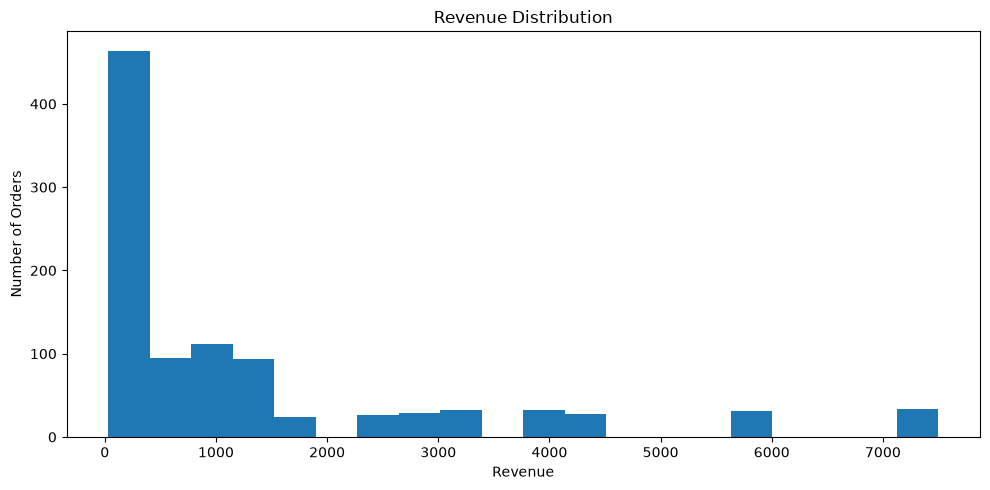

In [70]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["Revenue"],
    bins=20
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

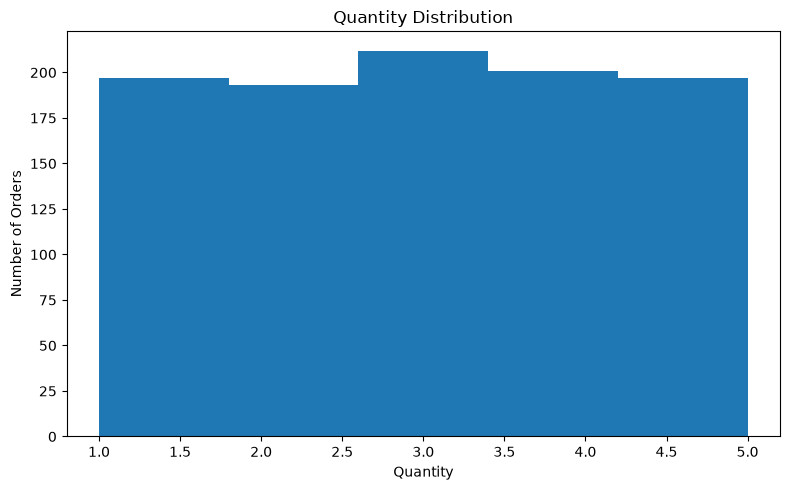

In [71]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Quantity"],
    bins=5
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [72]:
gender_analysis = (
    df.groupby("Gender")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Gender", "count"),
        Average_Order_Value=("Revenue", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

gender_analysis

,Revenue,Orders,Average_Order_Value
Gender,,,
Male,715590,524,1365.629771
Female,631010,476,1325.651261


In [73]:
age_group_analysis = (
    df.groupby("Age Group", observed=True)
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Age Group", "count"),
        Average_Order_Value=("Revenue", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

age_group_analysis

,Revenue,Orders,Average_Order_Value
Age Group,,,
46-55,437320,286,1529.090909
56+,413630,309,1338.608414
36-45,212940,172,1238.023256
26-35,163730,135,1212.814815
18-25,118980,98,1214.081633


In [74]:
final_kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity",
        "Unique Customers",
        "Average Order Value",
        "Total Returns",
        "Return Rate"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_quantity,
        unique_customers,
        round(average_order_value, 2),
        total_returns,
        round(return_rate, 2)
    ]
})

final_kpis

,Metric,Value
0,Total Revenue,1346600.0
1,Total Orders,1000.0
2,Total Quantity,3008.0
3,Unique Customers,292.0
4,Average Order Value,1346.6
5,Total Returns,308.0
6,Return Rate,30.8


In [75]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate Rows:", df.duplicated().sum())
print("Missing Values:", df.isnull().sum().sum())

Rows: 1000
Columns: 25
Duplicate Rows: 0
Missing Values: 0


In [76]:
df.to_csv(
    r"C:\Users\asus\OneDrive\Documents\Ecommerce-Sales-Analytics\Data\Cleaned\ecommerce_sales_final.csv",
    index=False
)

In [79]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 1000
Columns: 25


In [78]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [80]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [81]:
df.columns.tolist()

['Customer ID',
 'Gender',
 'Region',
 'Age',
 'Product Name',
 'Category',
 'Unit Price',
 'Quantity',
 'Total Price',
 'Shipping Fee',
 'Shipping Status',
 'Order Date',
 'Difference',
 'Price Check',
 'Year',
 'Month',
 'Month Name',
 'Quarter',
 'Year Month',
 'Age Group',
 'Delivered Flag',
 'Returned Flag',
 'In Transit Flag',
 'Revenue',
 'Order Value Segment']

In [82]:
final_kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Quantity",
        "Unique Customers",
        "Average Order Value",
        "Total Returns",
        "Return Rate"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_quantity,
        unique_customers,
        round(average_order_value, 2),
        total_returns,
        round(return_rate, 2)
    ]
})

final_kpis

,Metric,Value
0,Total Revenue,1346600.0
1,Total Orders,1000.0
2,Total Quantity,3008.0
3,Unique Customers,292.0
4,Average Order Value,1346.6
5,Total Returns,308.0
6,Return Rate,30.8


In [83]:
df.to_csv(
    r"C:\Users\asus\OneDrive\Documents\Ecommerce-Sales-Analytics\Data\Cleaned\ecommerce_sales_final.csv",
    index=False
)

In [84]:
import os

os.path.exists(
    r"C:\Users\asus\OneDrive\Documents\Ecommerce-Sales-Analytics\Data\Cleaned\ecommerce_sales_final.csv"
)

True